In [1]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow.keras import layers
import pathlib  # 객체지향 방식으로 파일 경로를 다룸
import urllib.request # url을 통해 파일 다운로드 기능 제공
import tarfile

def get_dataset_path():
    # 현재 실행 중인 파이썬 파일(또는 주피터 노트북)의 위치를 기준으로 경로 설정
    # 만약 절대 경로를 쓰고 싶다면 r"C:\Users\...\aircraftdatasets\4000pcs" 처럼 직접 입력하셔도 됩니다.
    dataset_dir = os.path.join(os.getcwd(), 'aircraftdatasets', '4000pcs')

    # 해당 경로가 실제로 존재하는지 검증
    if not os.path.exists(dataset_dir):
        raise FileNotFoundError(f"경로를 찾을 수 없습니다: {dataset_dir}\n"
                                "파이썬 실행 위치와 aircraftdatasets 폴더 위치를 확인해주세요.")
    
    print(f"✅ 데이터셋 경로 연결 완료: {dataset_dir}")
    return dataset_dir

# 경로 변수 할당
data_dir = get_dataset_path()

✅ 데이터셋 경로 연결 완료: c:\Users\human-31\project\ydataprofiling\aircraftdatasets\4000pcs


In [2]:
if data_dir:
    # 폴더명 리스트 (이미지 캡처본 기준)
    class_names = ['crack', 'dent', 'missing-head', 'paint-off', 'scratch']
    
    print("\n--- 클래스별 데이터 개수 확인 ---")
    total_images = 0
    for cls in class_names:
        cls_path = os.path.join(data_dir, cls)
        
        # 해당 폴더 내의 모든 파일 개수 카운트
        if os.path.exists(cls_path):
            images = glob.glob(os.path.join(cls_path, '*.*'))
            count = len(images)
            total_images += count
            print(f"[{cls}]: {count}장")
        else:
            print(f"[{cls}]: ⚠️ 폴더를 찾을 수 없습니다.")
            
    print(f"---------------------------------")
    print(f"총 데이터 개수: {total_images}장")


--- 클래스별 데이터 개수 확인 ---
[crack]: 996장
[dent]: 1346장
[missing-head]: 928장
[paint-off]: 789장
[scratch]: 222장
---------------------------------
총 데이터 개수: 4281장


In [3]:
# 데이터 다운로드 및 경로 설정
data_dir = get_dataset_path()  # 함수호출
data_dir = pathlib.Path(data_dir)

✅ 데이터셋 경로 연결 완료: c:\Users\human-31\project\ydataprofiling\aircraftdatasets\4000pcs


In [4]:
classes = sorted([item.name for item in data_dir.glob('*/') if item.is_dir()])  # 리스트 컴프리헨션을 사용하여 각 디렉터리의 이름(예: 'daisy', 'dandelion' 등)만 추출
image_count = len(list(data_dir.glob('*/*.jpg')))
print(f"발견된 클래스: {classes}")
print(f"총 이미지 개수: {image_count}")

발견된 클래스: ['crack', 'dent', 'missing-head', 'paint-off', 'scratch']
총 이미지 개수: 4281


In [5]:
for class_name in classes:
    class_images = len(list(data_dir.glob(f'{class_name}/*')))
    print(f"{class_name}: {class_images}개 이미지")

crack: 996개 이미지
dent: 1346개 이미지
missing-head: 928개 이미지
paint-off: 789개 이미지
scratch: 222개 이미지


In [6]:
img_height = 180
img_width = 180
batch_size = 32

In [7]:
# 1. 데이터셋 로드 (Training)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(data_dir),
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 2. 데이터셋 로드 (Validation)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    str(data_dir),
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 3. 클래스 이름 및 개수 파악
class_names = train_ds.class_names
print(f"클래스 목록: {class_names}")

# 직접 입력하신 개수를 기반으로 가중치 계산
# 순서: crack, dent, missing-head, paint-off, scratch
counts = [996, 1346, 928, 789, 222]
total = sum(counts)
num_classes = len(counts)

# 클래스별 가중치 산출 (전체 / (클래스수 * 개별수))
class_weights = {i: total / (num_classes * count) for i, count in enumerate(counts)}

print("계산된 클래스 가중치:", class_weights)

Found 4281 files belonging to 5 classes.
Using 3425 files for training.
Found 4281 files belonging to 5 classes.
Using 856 files for validation.
클래스 목록: ['crack', 'dent', 'missing-head', 'paint-off', 'scratch']
계산된 클래스 가중치: {0: 0.8596385542168675, 1: 0.6361069836552748, 2: 0.9226293103448275, 3: 1.0851711026615969, 4: 3.8567567567567567}


In [ ]:
# 4. 모델 설계 (MobileNetV2 활용)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"), # 수평, 수직 반전
  layers.RandomRotation(0.2),                   # 20% 범위 내 무작위 회전
])

model = tf.keras.Sequential([
    data_augmentation,
    # 스케일링 대신 배치 정규화(BatchNormalization)를 쓰면 CPU에서도 학습이 훨씬 빠르고 안정적입니다.
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(), # 학습 속도 향상 핵심
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    
    layers.Dropout(0.3), # 약간 높임
    layers.Flatten(),
    layers.Dense(256, activation='relu'), # 128에서 256으로 확장
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 학습 시 이전에 계산한 class_weights를 반드시 적용하세요!
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights 
)

C:\Users\human-31\AppData\Local\Temp\ipykernel_26104\3391232165.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


NameError: name 'data_augmentation' is not defined

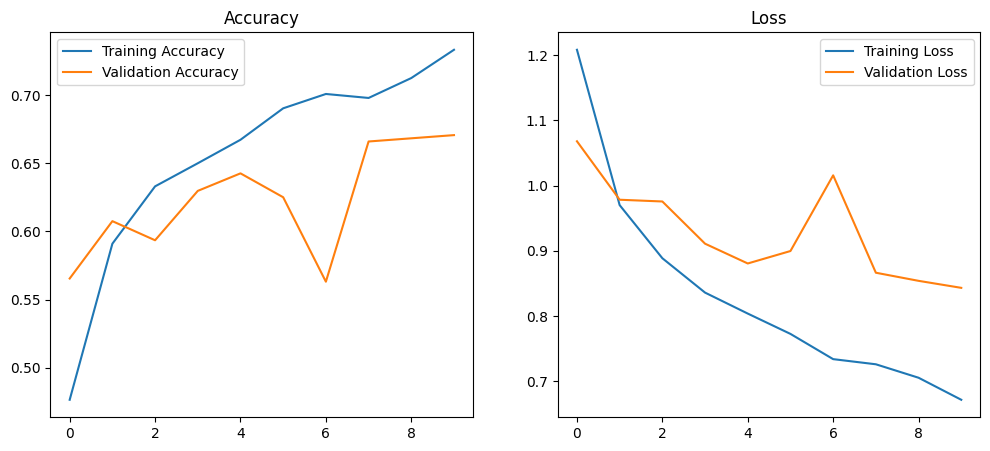

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

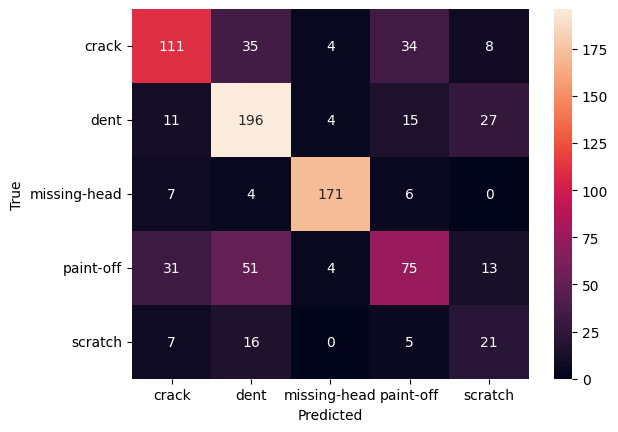

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 예측값 생성
y_pred = []
y_true = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# 리포트 출력
print(classification_report(y_true, y_pred, target_names=class_names))

# 히트맵 시각화
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
model.save('aircraft_defect_model_v1.h5')
print("✅ 모델 저장 완료!")

✅ 모델 저장 완료!
